# Independence & Covariance

独立性是"一个变量不携带另一个的信息"的精确化；协方差矩阵把"多变量一起变"的结构装进一个对称半正定矩阵——正好复用线性代数的全部工具。


## 0. 环境配置与导入


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


## 1. 独立性


$X, Y$ 独立当且仅当：

$$p(x, y) = p(x)\,p(y) \quad\text{对所有 } x, y$$

等价地：$\mathbb{E}[f(X)g(Y)] = \mathbb{E}[f(X)]\,\mathbb{E}[g(Y)]$。独立 ⇒ 不相关（协方差为 0），**但反过来不成立**——下面这个反例是理解"相关 ≠ 依赖"的关键。


相关系数 ρ = -0.0062（≈ 0，线性无关）
但 E[X²Y] = 0.1998 ≠ E[X²]·E[Y] = 0.1108
→ 明显依赖（Y 由 X 决定），却零相关：相关只度量『线性』关系


Text(0.5, 1.0, '抛物线关系：ρ≈0 但完全不独立')

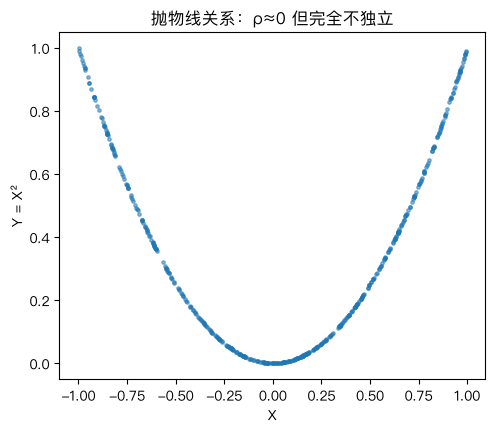

In [2]:
# 反例：X ~ U(-1,1)，Y = X²
rng = np.random.default_rng(0)
X = rng.uniform(-1, 1, 100000)
Y = X**2

print(f"相关系数 ρ = {np.corrcoef(X, Y)[0,1]:.4f}（≈ 0，线性无关）")
print(f"但 E[X²Y] = {np.mean(X**2*Y):.4f} ≠ E[X²]·E[Y] = {np.mean(X**2)*np.mean(Y):.4f}")
print("→ 明显依赖（Y 由 X 决定），却零相关：相关只度量『线性』关系")

xs = np.linspace(-1, 1, 100)
plt.figure(figsize=(5.5, 4.5))
plt.scatter(X[:500], Y[:500], s=6, alpha=0.5)
plt.xlabel('X'); plt.ylabel('Y = X²')
plt.title('抛物线关系：ρ≈0 但完全不独立')


## 2. 协方差矩阵：多变量的方差


对随机向量 $X = (X_1, \dots, X_n)$，协方差矩阵：

$$\Sigma_{ij} = \mathrm{Cov}(X_i, X_j), \qquad \Sigma = \mathbb{E}\big[(X-\mu)(X-\mu)^\mathsf{T}\big]$$

**性质**：对称、**半正定**（对任意 $v$，$v^\mathsf{T}\Sigma v = \mathrm{Var}(v^\mathsf{T}X) \ge 0$）——与 linear-algebra 07 的正定矩阵理论无缝衔接。


In [3]:
# 二维高斯采样：X = μ + L·Z（Cholesky 分解，呼应线代矩阵分解）
mu = np.array([0.0, 0.0])
Sigma = np.array([[2.0, 0.8], [0.8, 1.0]])
L = np.linalg.cholesky(Sigma)              # Σ = L Lᵀ

Z = rng.standard_normal((5000, 2))
X = Z @ L.T + mu                            # 采样

print("样本协方差矩阵:\n", np.round(np.cov(X.T), 3))
print("真实 Σ:\n", Sigma)
print("Σ 特征值:", np.linalg.eigvalsh(Sigma), "（全为正 → 正定）")


样本协方差矩阵:
 [[1.988 0.8  ]
 [0.8   1.006]]
真实 Σ:
 [[2.  0.8]
 [0.8 1. ]]
Σ 特征值: [0.55660189 2.44339811] （全为正 → 正定）


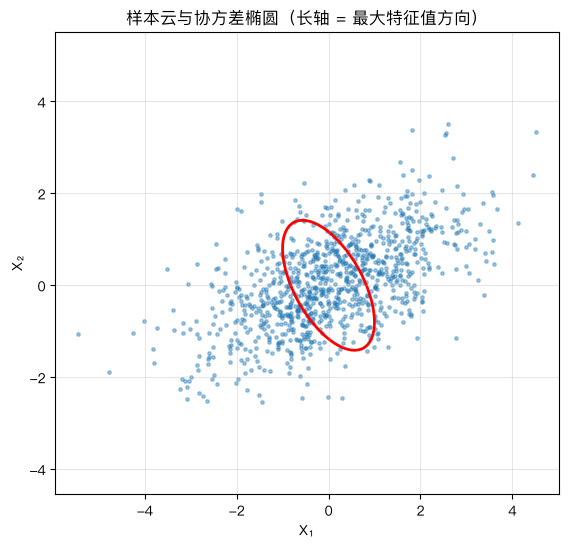

In [4]:
# 协方差椭圆可视化
evals, evecs = np.linalg.eigh(Sigma)
angle = np.degrees(np.arctan2(evecs[1, 1], evecs[0, 1]))
w, h = 2 * np.sqrt(evals)

plt.figure(figsize=(6.5, 6))
plt.scatter(X[:1000, 0], X[:1000, 1], s=6, alpha=0.4)
ell = plt.matplotlib.patches.Ellipse(mu, w, h, angle=angle, fill=False,
                                     edgecolor='red', linewidth=2)
plt.gca().add_patch(ell)
plt.xlabel('X₁'); plt.ylabel('X₂')
plt.title('样本云与协方差椭圆（长轴 = 最大特征值方向）')
plt.axis('equal'); plt.grid(alpha=0.3)


## 3. 多元正态分布 MVN


$$p(x) = \frac{1}{\sqrt{(2\pi)^n \det\Sigma}}\exp\Big(-\tfrac12 (x-\mu)^\mathsf{T}\Sigma^{-1}(x-\mu)\Big)$$

指数里的 $(x-\mu)^\mathsf{T}\Sigma^{-1}(x-\mu)$ 是**马氏距离**的平方——不是欧氏距离，而是"按协方差缩放过的距离"。等高线是椭圆（2D），主轴方向 = 特征向量。


In [5]:
def mvn_pdf(x, mu, Sigma):
    d = len(mu)
    diff = x - mu
    inv = np.linalg.inv(Sigma)
    return np.exp(-0.5 * diff @ inv @ diff) / np.sqrt((2*np.pi)**d * np.linalg.det(Sigma))

# 数值验证：概率密度全域积分 = 1
xs = np.linspace(-6, 6, 80); ys = np.linspace(-6, 6, 80)
Xg, Yg = np.meshgrid(xs, ys)
Z = np.array([mvn_pdf(np.array([x, y]), mu, Sigma) for x, y in zip(Xg.ravel(), Yg.ravel())])
total = Z.sum() * (xs[1]-xs[0]) * (ys[1]-ys[0])
print(f"MVN 密度全域数值积分 = {total:.4f}（应为 1）")


MVN 密度全域数值积分 = 1.0000（应为 1）


## 4. 白化与 PCA 预告


协方差矩阵的特征分解（呼应线代 04）：

$$\Sigma = U\Lambda U^\mathsf{T}$$

- 特征向量 $U$：数据"分散"的主方向（PCA 的主成分）
- 特征值 $\Lambda$：各方向上的方差大小
- **白化** $Z = \Lambda^{-1/2}U^\mathsf{T}(X-\mu)$：把数据旋转到主方向再按方差缩放，得到协方差为 $I$ 的"白"数据

深度学习中：批归一化（BN）就是在做"逐特征的近似白化"。


In [6]:
# 白化演示：变换后协方差应为单位阵
Xw = X @ evecs / np.sqrt(evals)          # 旋转 + 缩放
print("白化后协方差:\n", np.round(np.cov(Xw.T), 3))
print("（对角 ≈ 1，非对角 ≈ 0 → 白数据）")


白化后协方差:
 [[1.003 0.007]
 [0.007 0.997]]
（对角 ≈ 1，非对角 ≈ 0 → 白数据）


## 5. 与深度学习的关系


- **特征相关性**：输入特征相关时，损失曲面病态（呼应 calculus 04 条件数）
- **归一化层**：BatchNorm 逐通道做标准化（白化的廉价版），稳定训练
- **表示学习**：好的表示 = 特征尽量独立/解耦（PCA、ICA 思想）
- **采样**：生成模型从 $N(0, I)$ 采样，再通过线性变换得到任意 MVN（第 07 课）


## 课后练习


1. **证明**：$v^\mathsf{T}\Sigma v = \mathrm{Var}(v^\mathsf{T}X)$，并由此推出 $\Sigma$ 半正定。
2. **手算**：$\Sigma = [[4, 1], [1, 1]]$，求特征值与特征向量，画出协方差椭圆主轴方向。
3. **独立 ⇒ 不相关**：从 $p(x,y)=p(x)p(y)$ 出发证明 $\mathrm{Cov}(X,Y)=0$。
4. **白化**：对 $\Sigma = [[3, 1.2], [1.2, 1.5]]$ 重跑白化，验证结果协方差近似单位阵。
5. **思考**：为什么 BN 只在 batch 维度统计（而不是全特征协方差）？代价是什么？
